In [1]:
import os
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import curve_fit
import statsmodels.api as sm
import statsmodels.formula.api as smf

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

trf_locations = sorted(
    glob.glob(
        os.path.join('experiments', '*', 'trf')
    ), key = lambda x: int(x.split(os.path.sep)[1])
)
lstm_locations = sorted(
    glob.glob(
        os.path.join('experiments', '*', 'lstm')
    ), key = lambda x: int(x.split(os.path.sep)[1])
)

markers = [
    'o', '*', 'x', '+', 's', 'D', 'p', 'h', 'v', '^'
]

MAX_LOGS = 20

In [2]:
def select_data(
    model_type = None,
    grammar_type = None,
    num_symbols = None,
    num_states_or_nts = None
):
    if model_type == 'trf':
        locs = trf_locations
    elif model_type == 'lstm':
        locs = lstm_locations
    elif model_type is None:
        locs = trf_locations + lstm_locations
        
    dfs = []
        
    for loc in locs:
        hparams = json.load(open(os.path.join(loc, 'hparams.json')))
        if grammar_type is not None and hparams['grammar_type'] != grammar_type:
            continue
        if num_symbols is not None and hparams['grammar_num_symbols'] != num_symbols:
            continue
        if num_states_or_nts is not None and hparams['grammar_formalism_arg'] != num_states_or_nts:
            continue
        dfs.append(pd.read_csv(os.path.join(loc, 'length_wise_metrics.tsv'), sep='\t'))
    
    if len(dfs) == 0:
        print('No data found')
        
    return dfs

In [3]:
def slac_plot(datas, names, by_seq=False, avg=False):
    
    if by_seq:
        plt.figure()
        
        for data_idx, (data, name) in enumerate(zip(datas, names)):
            x = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            y = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            counts = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}

            for df in data:
                for seq_len in range(1, 11):
                    subset = df[df['seq_len'] == seq_len]
                    
                    x_i = subset['step'].to_numpy()
                    y_i = subset['rho'].to_numpy()
                    
                    assert len(x_i) == len(y_i)
                    
                    if len(x_i) > MAX_LOGS:
                        x_i = x_i[:MAX_LOGS]
                        y_i = y_i[:MAX_LOGS]
                    
                    x[seq_len][:len(x_i)] += x_i
                    y[seq_len][:len(y_i)] += y_i
                    counts[seq_len][:len(x_i)] += 1

            for seq_len in range(1, 11):
                valid_mask = counts[seq_len] > 0

                plt.scatter(
                    x[seq_len][valid_mask] / counts[seq_len][valid_mask],
                    y[seq_len][valid_mask] / counts[seq_len][valid_mask],
                    label=f'{name}, len={seq_len}',
                    c=colors[seq_len-1],
                    s=6,
                    marker=markers[data_idx]
                )

        plt.grid()
        plt.title('Rho vs step by sequence length')
        plt.ylabel('Rho, grouped by sequence length')
        plt.xlabel('Training steps')
        plt.legend(loc='lower right')
        plt.show()

    if avg:
        plt.figure()
        
        for data_idx, (data, name) in enumerate(zip(datas, names)):
            x = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            y = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            counts = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}

            for df in data:
                for seq_len in range(1, 11):
                    subset = df[df['seq_len'] == seq_len]
                    
                    x_i = subset['step'].to_numpy()
                    y_i = subset['rho'].to_numpy()
                    
                    assert len(x_i) == len(y_i)
                    
                    if len(x_i) > MAX_LOGS:
                        x_i = x_i[:MAX_LOGS]
                        y_i = y_i[:MAX_LOGS]
                    
                    x[seq_len][:len(x_i)] += x_i
                    y[seq_len][:len(y_i)] += y_i
                    counts[seq_len][:len(x_i)] += 1
            
            x_avg = np.zeros((MAX_LOGS,))
            y_avg = np.zeros((MAX_LOGS,))
            counts_total = np.zeros((MAX_LOGS,))

            for seq_len in range(1, 11):
                valid_mask = counts[seq_len] > 0
                x_avg[valid_mask] += x[seq_len][valid_mask] / counts[seq_len][valid_mask]
                y_avg[valid_mask] += y[seq_len][valid_mask] / counts[seq_len][valid_mask]
                counts_total[valid_mask] += 1

            # Average across sequence lengths
            valid_mask = counts_total > 0
            x_avg[valid_mask] /= counts_total[valid_mask]
            y_avg[valid_mask] /= counts_total[valid_mask]

            plt.scatter(
                x_avg[valid_mask],
                y_avg[valid_mask],
                label=name,
                s=6,
                marker=markers[data_idx]
            )

        plt.grid()
        plt.title('SLAC@(1,10)')
        plt.ylabel('Rho')
        plt.xlabel('Training steps')
        plt.legend(loc='lower right')
        plt.show()

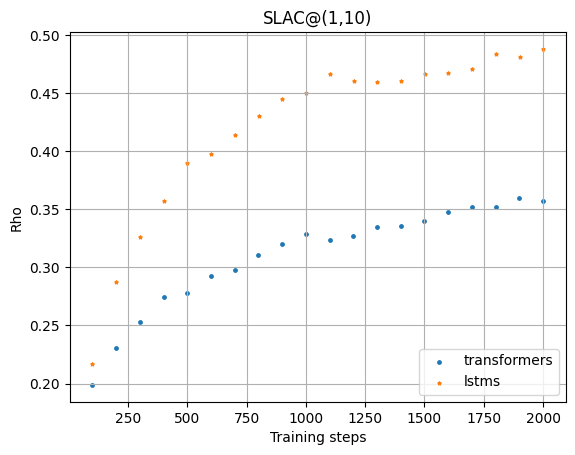

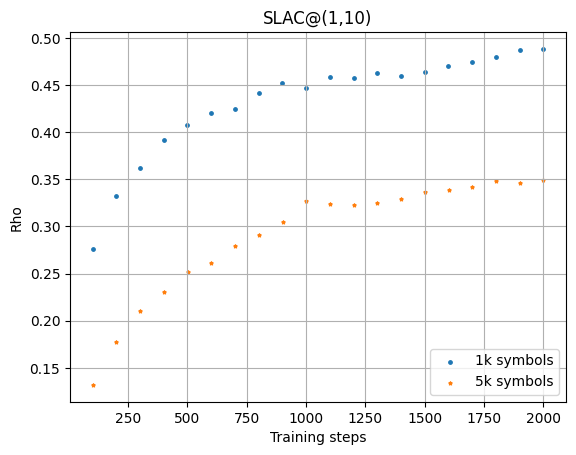

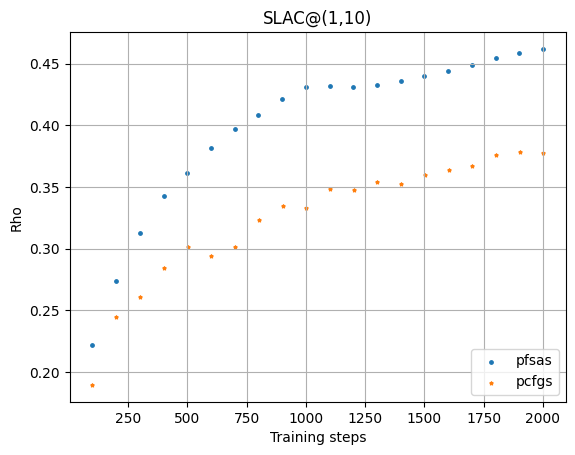

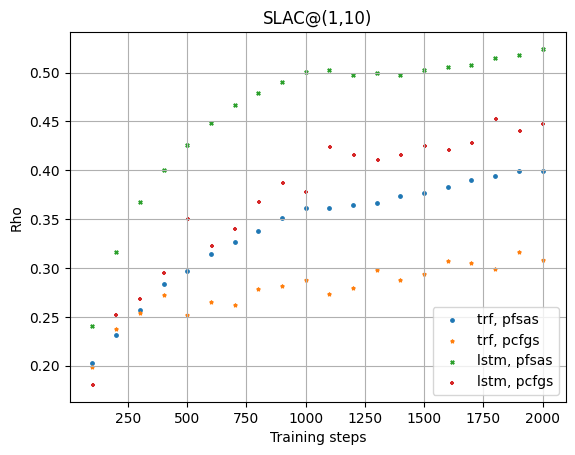

In [ ]:
slac_plot(
    (select_data(model_type='trf'), select_data(model_type='lstm')), 
    ('transformers', 'lstms'), 
    avg=True
)

slac_plot(
    (select_data(num_symbols=1000), select_data(num_symbols=5000)),
    ('1k symbols', '5k symbols'),
    avg=True
)

slac_plot(
    (select_data(grammar_type='pfsa'), select_data(grammar_type='pcfg')),
    ('pfsas', 'pcfgs'),
    avg=True
)

slac_plot(
    (
        select_data(grammar_type='pfsa', model_type='trf'),
        select_data(grammar_type='pcfg', model_type='trf'),
        select_data(grammar_type='pfsa', model_type='lstm'),
        select_data(grammar_type='pcfg', model_type='lstm')
    ),
    ('trf, pfsas', 'trf, pcfgs', 'lstm, pfsas', 'lstm, pcfgs'),
    avg=True
)


In [ ]:
# regressions
# predict SLAC or correlation coeffs from entropy, vocab size, num states, model type, grammar type

# model = smf.mixedlm(
#     'max_rho_num_steps ~ num_symbols + num_states + lstm_or_trf + entropy',
#     groups=df['seed'],
#     data=df
# )

In [7]:
# separate regressions broken down by model type, grammar type, vocab size, num states